In [ ]:
import pandas as pd
from google.colab import files
import io

# Upload a file. A file selection dialog will appear. Choose your CSV file.
uploaded = files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Read the uploaded file into a DataFrame
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

# Display the first 5 rows of the DataFrame
display(df.head())

Saving cancer_data.csv to cancer_data.csv
User uploaded file "cancer_data.csv" with length 34286266 bytes


,0,1,2,3,4,5,6,7,8,9,...,962,963,964,965,966,967,968,969,970,971
0,44.023542,9.216286,11.319078,33.215176,16.901427,9.031338,1.109961,20.017821,16.724363,10.494192,...,21.706486,16.315579,4.224009,8.602081,23.762341,8.302416,1.408731,4.295620,8.768768,1.0
1,29.746157,9.765600,40.540128,30.169134,20.047393,32.237287,2.460624,17.029112,28.346167,17.017284,...,12.815215,10.150965,8.914809,6.797915,15.379187,11.420690,6.599729,3.819019,5.758501,1.0
2,35.799315,9.884781,3.886043,29.984211,17.135946,21.273727,1.501203,20.598204,25.855152,12.275738,...,14.344729,11.224647,7.870991,7.724003,25.762396,8.628786,4.104879,4.382387,5.306177,1.0
3,26.490401,7.085828,10.804003,23.482255,17.044085,14.880104,1.299056,14.978582,31.214294,10.015235,...,13.660995,9.730124,7.804760,5.030966,8.964868,7.990036,4.251886,3.702483,7.500498,1.0
4,27.632466,7.642971,3.670265,16.584843,20.375321,22.174600,1.553541,14.909150,54.435490,13.392213,...,16.650019,8.584938,7.485410,5.945771,9.205302,8.761025,4.656969,3.827945,7.939863,1.0


In [ ]:
print('DataFrame Info:')
df.info()

print('\nDataFrame Columns:')
print(df.columns)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2086 entries, 0 to 2085
Columns: 972 entries, 0 to 971
dtypes: float64(972)
memory usage: 15.5 MB

DataFrame Columns:
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '962', '963', '964', '965', '966', '967', '968', '969', '970', '971'],
      dtype='object', length=972)


### Data Preprocessing: Separating Features and Labels, and Applying Min-Max Scaling

I'll start by separating the features (all columns except the last one, '971') into `X` and the labels (column '971') into `y`. Then, I'll apply `MinMaxScaler` from `sklearn.preprocessing` to scale the feature data to a range between 0 and 1. This helps in normalizing the input features and can improve the performance of many machine learning algorithms.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Assuming the last column '971' is the label
# Separate features (X) and labels (y)
X = df.iloc[:, :-1] # All columns except the last one
y = df.iloc[:, -1]  # The last column

print("Shape of features (X):", X.shape)
print("Shape of labels (y):", y.shape)

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Apply Min-Max Scaling to the features
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFirst 5 rows of scaled features (X_scaled_df):")
display(X_scaled_df.head())

print("\nFirst 5 values of labels (y):")
display(y.head())

Shape of features (X): (2086, 971)
Shape of labels (y): (2086,)

First 5 rows of scaled features (X_scaled_df):


,0,1,2,3,4,5,6,7,8,9,...,961,962,963,964,965,966,967,968,969,970
0,0.237892,0.082832,0.020102,0.302737,0.050826,0.046596,0.013514,0.497457,0.038969,0.084320,...,0.069896,0.168754,0.341778,0.049079,0.186027,0.093705,0.112600,0.033977,0.092447,0.217877
1,0.145298,0.088527,0.077114,0.272476,0.061027,0.225673,0.034881,0.416975,0.069264,0.144424,...,0.165745,0.096844,0.195057,0.116374,0.143712,0.059204,0.162041,0.219174,0.081110,0.136299
2,0.184555,0.089762,0.005600,0.270638,0.051586,0.141069,0.019703,0.513086,0.062771,0.100735,...,0.109929,0.109214,0.220611,0.101399,0.165433,0.101937,0.117775,0.130167,0.094511,0.124041
3,0.124184,0.060745,0.019098,0.206044,0.051288,0.091730,0.016505,0.361757,0.076741,0.079907,...,0.127341,0.103684,0.185041,0.100449,0.102269,0.032805,0.107647,0.135411,0.078338,0.183507
4,0.131590,0.066521,0.005179,0.137520,0.062090,0.148021,0.020531,0.359887,0.137273,0.111023,...,0.139652,0.127859,0.157785,0.095868,0.123725,0.033795,0.119871,0.149863,0.081322,0.195414



First 5 values of labels (y):


,971
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


### Data Splitting and Adaptive XGBoost Modeling

Before training any models, it's crucial to split the data into training and testing sets. This allows us to evaluate how well our models generalize to unseen data. I'll use a 80/20 split for training and testing.

Next, to address the 'adaptive XGBoost' request, I'll train an `XGBoostRegressor` model using different subsets of the top features. I'll use `SelectKBest` with the `f_regression` scoring function to identify the top `k` features from the scaled training data. For each `k` (60, 80, 100, 120), I'll:
1. Select the top `k` features.
2. Train an `XGBoostRegressor`.
3. Evaluate the model's performance on the test set using the R-squared score.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

# Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1668, 971)
X_test shape: (418, 971)
y_train shape: (1668,)
y_test shape: (418,)


### Adaptive XGBoost Feature Ranking and Top-N Gene Selection

This section focuses on using XGBoost's built-in feature importance mechanism for feature selection. I will perform the following steps:
1. Train an `XGBoostRegressor` on the complete `X_train` dataset to obtain feature importance scores.
2. Rank the features based on these importance scores.
3. For predefined values of N (60, 80, 100), select the top N features.
4. Train a new `XGBoostRegressor` model for each set of selected features.
5. Evaluate the performance of each model on the test set.

In [ ]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

# 1. Train an XGBoost model on the full training data to get feature importances
print("Training initial XGBoost model for feature importance...")
initial_xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
initial_xgb_model.fit(X_train, y_train)

# Get feature importances
feature_importances = initial_xgb_model.feature_importances_

# Create a DataFrame for easier sorting
importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

print("\nTop 10 features by importance:")
display(importance_df.head(10))

Training initial XGBoost model for feature importance...

Top 10 features by importance:


,feature,importance
497,497,0.317188
324,324,0.174233
491,491,0.051483
563,563,0.049869
334,334,0.046153
372,372,0.038790
340,340,0.032310
444,444,0.017135
499,499,0.016869
131,131,0.015423


In [ ]:
# Define the numbers of top features to select
k_features_list_xgb = [60, 80, 100, 120]

results_xgb_ranking = {}

for k in k_features_list_xgb:
    print(f"\n--- Training with top {k} features based on XGBoost ranking ---")

    # Select top K features based on pre-calculated importances
    top_k_features = importance_df['feature'].head(k).tolist()

    X_train_selected_xgb = X_train[top_k_features]
    X_test_selected_xgb = X_test[top_k_features]

    print(f"Selected {len(top_k_features)} features. Example: {top_k_features[:5]}...")

    # Initialize and train a new XGBoost Regressor for the selected features
    xgb_model_k = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
    xgb_model_k.fit(X_train_selected_xgb, y_train)

    # Make predictions
    y_pred_k = xgb_model_k.predict(X_test_selected_xgb)

    # Evaluate the model
    r2_k = r2_score(y_test, y_pred_k)
    mse_k = mean_squared_error(y_test, y_pred_k)

    print(f"R-squared (R2) score with {k} features: {r2_k:.4f}")
    print(f"Mean Squared Error (MSE) with {k} features: {mse_k:.4f}")

    results_xgb_ranking[k] = {'R2_score': r2_k, 'MSE': mse_k}

# Display all results
print("\n--- Summary of XGBoost Feature Ranking Results ---")
for k, metrics in results_xgb_ranking.items():
    print(f"Features: {k}, R2 Score: {metrics['R2_score']:.4f}, MSE: {metrics['MSE']:.4f}")


--- Training with top 60 features based on XGBoost ranking ---
Selected 60 features. Example: ['497', '324', '491', '563', '334']...
R-squared (R2) score with 60 features: 0.9410
Mean Squared Error (MSE) with 60 features: 0.1143

--- Training with top 80 features based on XGBoost ranking ---
Selected 80 features. Example: ['497', '324', '491', '563', '334']...
R-squared (R2) score with 80 features: 0.9418
Mean Squared Error (MSE) with 80 features: 0.1128

--- Training with top 100 features based on XGBoost ranking ---
Selected 100 features. Example: ['497', '324', '491', '563', '334']...
R-squared (R2) score with 100 features: 0.9336
Mean Squared Error (MSE) with 100 features: 0.1288

--- Training with top 120 features based on XGBoost ranking ---
Selected 120 features. Example: ['497', '324', '491', '563', '334']...
R-squared (R2) score with 120 features: 0.9295
Mean Squared Error (MSE) with 120 features: 0.1366

--- Summary of XGBoost Feature Ranking Results ---
Features: 60, R2 Sco

### Transformer Encoder Model Setup

Let's define a light-weight Transformer Encoder model. We'll use TensorFlow/Keras to build the model. The model will consist of:
- An embedding layer to convert input features into a higher-dimensional space.
- Multiple Transformer Blocks, each containing multi-head self-attention and a feed-forward network.
- Dropout layers for regularization.
- A final dense layer for regression output.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the Transformer Block
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation="relu"),
                layers.Dense(embed_dim),
            ]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(query=inputs, value=inputs, key=inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Define the Token and Position Embedding Layer
# (This class is not directly used in the final model for continuous data, but kept for context)
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions


# Model Parameters
embed_dim = 64  # Embedding dimension for each gene
num_heads = 4   # Number of attention heads
ff_dim = 128    # Hidden layer size in feed forward network inside transformer
num_transformer_blocks = 2 # Number of transformer blocks
dropout_rate = 0.2

# For numerical features, a common approach is to embed each feature independently.
# Instead of TokenAndPositionEmbedding for discrete tokens, we use a simple Dense layer
# to project each feature into the `embed_dim` space, and then add positional encoding.

class FeatureAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, embed_dim):
        super().__init__()
        self.position_embedding = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)
        self.feature_linear_projection = layers.Dense(embed_dim) # To project each scalar feature into embed_dim space

    def call(self, x):
        # x has shape (batch_size, num_features)
        # We need to apply linear projection to each feature, treating it as a sequence item.
        # This means, first expand dims to (batch_size, num_features, 1)
        x = tf.expand_dims(x, -1) # Shape becomes (batch_size, num_features, 1)
        x = self.feature_linear_projection(x) # Shape becomes (batch_size, num_features, embed_dim)

        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        position_embeddings = self.position_embedding(positions) # Shape (num_features, embed_dim)

        return x + position_embeddings # Add broadcastable position embeddings


# Get the number of features (genes)
num_features = X_train.shape[1]
# Determine the number of classes (assuming labels 1.0 to 5.0, so 5 classes)
num_classes = int(y.max() - y.min() + 1)

inputs = layers.Input(shape=(num_features,))

# Apply the Feature and Position Embedding
x = FeatureAndPositionEmbedding(maxlen=num_features, embed_dim=embed_dim)(inputs)

# Add Transformer blocks
for _ in range(num_transformer_blocks):
    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

# Global average pooling to flatten the sequence of embeddings
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
# Output layer for multi-class classification
outputs = layers.Dense(num_classes, activation='softmax')(x)

transformer_model = keras.Model(inputs=inputs, outputs=outputs)

# Compile with classification loss and metrics
transformer_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

transformer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 971)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_and_position_embedding  │ (None, 971, 64)        │        62,272 │
│ (FeatureAndPositionEmbedding)   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 971, 64)        │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 971, 64)        │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,997 (894.52 KB)

 Trainable params: 228,997 (894.52 KB)

 Non-trainable params: 0 (0.00 B)

### Train and Evaluate the Transformer Encoder Model

Now that the model architecture is defined, we will train it using the `X_train` and `y_train` data. After training, we'll evaluate its performance on the `X_test` data using common regression metrics: Mean Squared Error (MSE), Mean Absolute Error (MAE), and R-squared (R2).

In [ ]:







       from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for better visualization

# Convert y_train and y_test to 0-indexed integers
y_train_int = (y_train.astype(int) - 1).values
y_test_int = (y_test.astype(int) - 1).values

# Convert pandas DataFrames to TensorFlow tensors for model training
X_train_tensor = tf.constant(X_train.values, dtype=tf.float32)
y_train_tensor = tf.constant(y_train_int, dtype=tf.int32) # Use integer labels for sparse_categorical_crossentropy
X_test_tensor = tf.constant(X_test.values, dtype=tf.float32)
y_test_tensor = tf.constant(y_test_int, dtype=tf.int32)   # Use integer labels for sparse_categorical_crossentropy

# Train the model
print("\nTraining the Transformer classification model...")
history = transformer_model.fit(
    X_train_tensor, y_train_tensor,
    batch_size=32,
    epochs=50, # You can adjust the number of epochs
    validation_split=0.2, # Use a part of the training data for validation
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

# Evaluate the model on the test set
print("\nEvaluating the Transformer classification model on the test set...")
loss, accuracy = transformer_model.evaluate(X_test_tensor, y_test_tensor)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions on the test set for classification metrics
y_pred_probabilities = transformer_model.predict(X_test_tensor)
y_pred_classes = tf.argmax(y_pred_probabilities, axis=1).numpy()

# Generate Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_tensor.numpy(), y_pred_classes)

# Plotting the confusion matrix as a heatmap with class labels
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[class_labels[i] for i in range(num_classes)],
            yticklabels=[class_labels[i] for i in range(num_classes)])
plt.title('Confusion Matrix for Transformer Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate Classification Report
print("\nClassification Report:")
cr = classification_report(y_test_tensor.numpy(), y_pred_classes, target_names=[class_labels[i] for i in range(num_classes)])
print(cr)


Training the Transformer classification model...
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 483s 11s/step - accuracy: 0.9670 - loss: 0.1108 - val_accuracy: 0.8802 - val_loss: 0.3739
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 465s 11s/step - accuracy: 0.9558 - loss: 0.1278 - val_accuracy: 0.9431 - val_loss: 0.1638
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 465s 11s/step - accuracy: 0.9798 - loss: 0.0540 - val_accuracy: 0.9491 - val_loss: 0.1522
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 493s 11s/step - accuracy: 0.9790 - loss: 0.0487 - val_accuracy: 0.9431 - val_loss: 0.1712
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 506s 11s/step - accuracy: 0.9798 - loss: 0.0520 - val_accuracy: 0.9341 - val_loss: 0.2248
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 514s 11s/step - accuracy: 0.9775 - loss: 0.0584 - val_accuracy: 0.9461 - val_loss: 0.1759
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 499s 11s/step - accuracy: 0.9550 - loss: 0.1445 - val_accuracy: 0.9281 - val_loss: 0.2113
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 462s 11s/step - 

### Apply Transformer Encoder Model to Top N XGBoost-Selected Features

We will now iterate through the top N feature sets (60, 80, 100, 120) identified by XGBoost feature ranking. For each set, we'll build, train, and evaluate a new Transformer Encoder classification model to assess its performance.

First, let's define a function to build the Transformer model, allowing us to dynamically set the `num_features` based on the current `N`.

In [ ]:
def build_transformer_classifier_model(num_features_input, num_classes_input, embed_dim, num_heads, ff_dim, num_transformer_blocks, dropout_rate):
    inputs = layers.Input(shape=(num_features_input,))
    x = FeatureAndPositionEmbedding(maxlen=num_features_input, embed_dim=embed_dim)(inputs)

    for _ in range(num_transformer_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes_input, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


k_features_list_xgb_for_transformer = [60, 80, 100, 120]
transformer_results_by_k = {}

for k in k_features_list_xgb_for_transformer:
    print(f"\n--- Training Transformer model with top {k} features based on XGBoost ranking ---")

    # Select top K features based on pre-calculated importances
    top_k_features = importance_df['feature'].head(k).tolist()

    X_train_selected_k = X_train[top_k_features]
    X_test_selected_k = X_test[top_k_features]

    print(f"Selected {len(top_k_features)} features for Transformer. Example: {top_k_features[:5]}...")

    # Build a new Transformer model for this subset of features
    current_transformer_model = build_transformer_classifier_model(
        num_features_input=k,
        num_classes_input=num_classes,
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim,
        num_transformer_blocks=num_transformer_blocks,
        dropout_rate=dropout_rate
    )

    # Convert selected features to TensorFlow tensors
    X_train_tensor_k = tf.constant(X_train_selected_k.values, dtype=tf.float32)
    X_test_tensor_k = tf.constant(X_test_selected_k.values, dtype=tf.float32)

    # Train the model
    history = current_transformer_model.fit(
        X_train_tensor_k, y_train_tensor,
        batch_size=32,
        epochs=50,
        validation_split=0.2,
        callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0 # Suppress verbose output for cleaner log
    )

    # Evaluate the model
    loss, accuracy = current_transformer_model.evaluate(X_test_tensor_k, y_test_tensor, verbose=0)
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")

    # Make predictions for classification metrics
    y_pred_probabilities_k = current_transformer_model.predict(X_test_tensor_k, verbose=0)
    y_pred_classes_k = tf.argmax(y_pred_probabilities_k, axis=1).numpy()

    # Generate Confusion Matrix
    cm_k = confusion_matrix(y_test_tensor.numpy(), y_pred_classes_k)
    print("Confusion Matrix:")
    print(cm_k)

    # Generate Classification Report
    cr_k = classification_report(y_test_tensor.numpy(), y_pred_classes_k)
    print("Classification Report:")
    print(cr_k)

    transformer_results_by_k[k] = {
        'Test Loss': loss,
        'Test Accuracy': accuracy,
        'Confusion Matrix': cm_k,
        'Classification Report': cr_k
    }

print("\n--- Summary of Transformer Model Performance with XGBoost-Selected Features ---")
for k, metrics in transformer_results_by_k.items():
    print(f"\nFeatures: {k}")
    print(f"  Test Accuracy: {metrics['Test Accuracy']:.4f}")
    print(f"  Test Loss: {metrics['Test Loss']:.4f}")
    # Only print full report if desired, otherwise, just summary stats
    # print(f"  Classification Report:\n{metrics['Classification Report']}")



--- Training Transformer model with top 60 features based on XGBoost ranking ---
Selected 60 features for Transformer. Example: ['497', '324', '491', '563', '334']...
Test Loss: 0.1145
Test Accuracy: 0.9617
Confusion Matrix:
[[183   0   0   1   0]
 [  1  96   0   0   0]
 [  0   0  36   5   1]
 [  1   0   6  43   0]
 [  1   0   0   0  44]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       184
           1       1.00      0.99      0.99        97
           2       0.86      0.86      0.86        42
           3       0.88      0.86      0.87        50
           4       0.98      0.98      0.98        45

    accuracy                           0.96       418
   macro avg       0.94      0.94      0.94       418
weighted avg       0.96      0.96      0.96       418


--- Training Transformer model with top 80 features based on XGBoost ranking ---
Selected 80 features for Transformer. Example: ['497', '324', '4

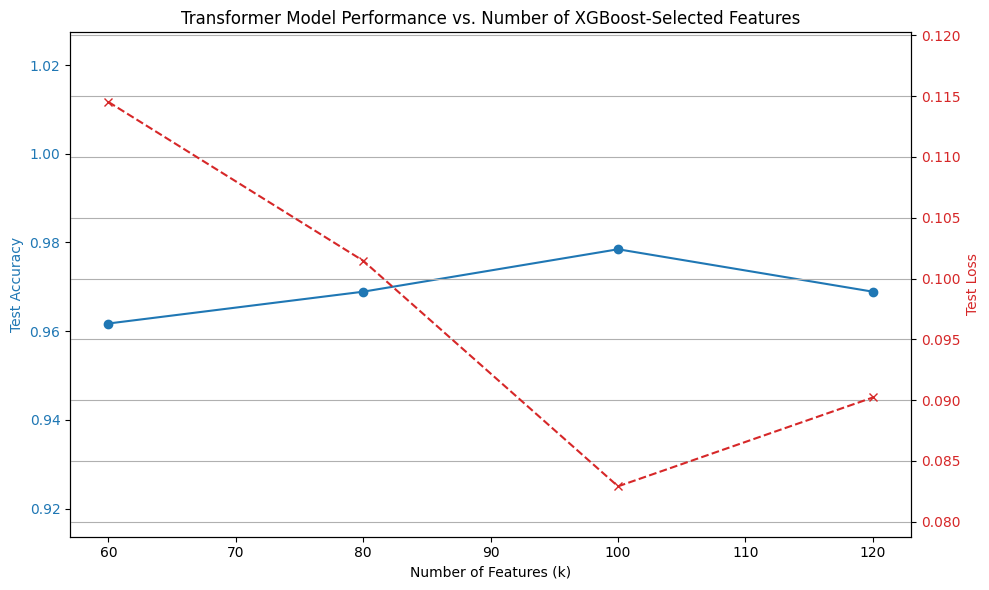

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data for plotting
k_values = sorted(list(transformer_results_by_k.keys()))
test_accuracies = [transformer_results_by_k[k]['Test Accuracy'] for k in k_values]
test_losses = [transformer_results_by_k[k]['Test Loss'] for k in k_values]

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Test Accuracy on the first y-axis
color = 'tab:blue'
ax1.set_xlabel('Number of Features (k)')
ax1.set_ylabel('Test Accuracy', color=color)
ax1.plot(k_values, test_accuracies, color=color, marker='o', linestyle='-')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim([min(test_accuracies) * 0.95, max(test_accuracies) * 1.05]) # Auto-adjust y-lim

# Create a second y-axis for Test Loss
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Test Loss', color=color)
ax2.plot(k_values, test_losses, color=color, marker='x', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim([min(test_losses) * 0.95, max(test_losses) * 1.05]) # Auto-adjust y-lim

plt.title('Transformer Model Performance vs. Number of XGBoost-Selected Features')
fig.tight_layout()
plt.grid(True)
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'ModelComparison'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "ModelComparison"] {type:"string"}

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Re-define TransformerBlock and FeatureAndPositionEmbedding for standalone execution
# Assuming global parameters like embed_dim, num_heads, ff_dim, num_transformer_blocks, dropout_rate, num_classes are available from previous runs

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation="relu"),
                layers.Dense(embed_dim),
            ]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(query=inputs, value=inputs, key=inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class FeatureAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, embed_dim):
        super().__init__()
        self.position_embedding = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)
        self.feature_linear_projection = layers.Dense(embed_dim)

    def call(self, x):
        x = tf.expand_dims(x, -1)
        x = self.feature_linear_projection(x)
        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        position_embeddings = self.position_embedding(positions)
        return x + position_embeddings

def build_transformer_classifier_model(num_features_input, num_classes_input, embed_dim, num_heads, ff_dim, num_transformer_blocks, dropout_rate):
    inputs = layers.Input(shape=(num_features_input,))
    x = FeatureAndPositionEmbedding(maxlen=num_features_input, embed_dim=embed_dim)(inputs)

    for _ in range(num_transformer_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes_input, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

# Best performing k identified previously
best_k = 100

# Select top K features based on pre-calculated importances (assuming importance_df is available)
top_k_features = importance_df['feature'].head(best_k).tolist()
X_train_selected_best_k = X_train[top_k_features]
X_test_selected_best_k = X_test[top_k_features]

# Convert selected features to TensorFlow tensors
X_train_tensor_best_k = tf.constant(X_train_selected_best_k.values, dtype=tf.float32)
X_test_tensor_best_k = tf.constant(X_test_selected_best_k.values, dtype=tf.float32)

# Build and train the best model
best_transformer_model = build_transformer_classifier_model(
    num_features_input=best_k,
    num_classes_input=num_classes, # Assuming num_classes is defined globally
    embed_dim=embed_dim,
    num_heads=num_heads,
    ff_dim=ff_dim,
    num_transformer_blocks=num_transformer_blocks,
    dropout_rate=dropout_rate
)

print(f"Training the best Transformer model with {best_k} features...")
history = best_transformer_model.fit(
    X_train_tensor_best_k, y_train_tensor, # Assuming y_train_tensor is defined globally
    batch_size=32,
    epochs=50, # You can adjust the number of epochs
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=0 # Suppress verbose output for cleaner log
)

# Predict probabilities
y_pred_proba = best_transformer_model.predict(X_test_tensor_best_k, verbose=0)

# Binarize the true labels for each class (assuming y_test_tensor is defined globally)
y_test_binarized = label_binarize(y_test_tensor, classes=np.arange(num_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', num_classes) # Using a colormap for distinct colors

for i in range(num_classes):
    # Use class_labels dictionary for names
    ax.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f'ROC curve of {class_labels[i]} (area = {roc_auc[i]:0.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random guess') # Random guess line
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Receiver Operating Characteristic (ROC) Curve for Multi-class Transformer Model')
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

Training the best Transformer model with 100 features...


LookupError: gradient registry has no entry for: shap_DivNoNan

In [ ]:
# Install the shap library
!pip install shap

Initializing KernelExplainer and calculating SHAP values for each class...
  Calculating SHAP values for class 0...


  0%|          | 0/5 [00:00<?, ?it/s]

  Calculating SHAP values for class 1...


  0%|          | 0/5 [00:00<?, ?it/s]

  Calculating SHAP values for class 2...


...

  0%|          | 0/5 [00:00<?, ?it/s]


Top 10 Genes based on SHAP Importance:


,feature,shap_importance
11,595,0.041731
81,861,0.028369
1,324,0.016982
3,563,0.016941
54,488,0.015641
25,767,0.010927
53,848,0.007306
19,98,0.005281
41,122,0.005189
21,81,0.005030



SHAP Summary Plot for Top Features:


/tmp/ipykernel_3589/2530016807.py:67: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(all_shap_values, sample_for_shap, feature_names=top_k_features, class_names=np.arange(num_classes).astype(str), show=False)


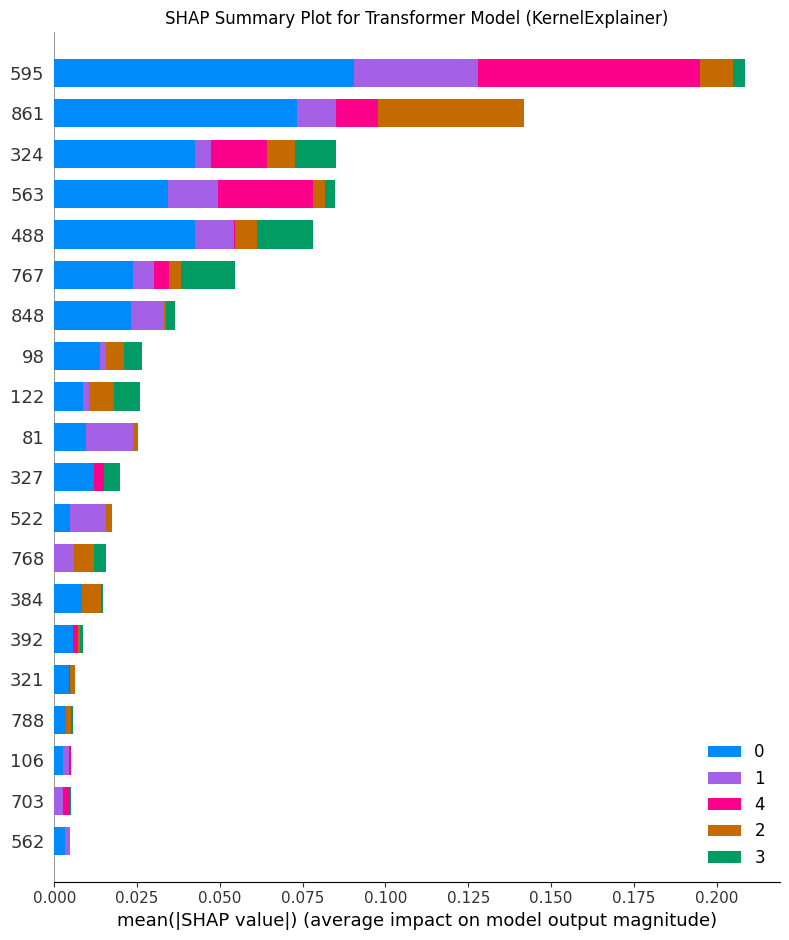

In [ ]:
import shap
import numpy as np
import pandas as pd
import tensorflow as tf # Import tensorflow if not already imported

# Assuming `best_transformer_model` and `X_test_selected_best_k` are already defined and populated.
# Also `top_k_features` should contain the names of the 100 features used by the best model.

# For KernelExplainer, a background dataset is needed.
# It's important that this background data also consists of the 'best_k' features.
# A small sample of the training data is typically used.
# Let's use a sample of X_train_selected_best_k as the background dataset
background_data_kernel = X_train_selected_best_k.sample(n=50, random_state=42) # Smaller sample for KernelExplainer speed

# Define the prediction function for KernelExplainer for a single class
# It should take a numpy array and return a numpy array of predictions for the specified class.
def model_predict_single_class(data, class_idx):
    # Ensure the input data is float32, as the model expects it
    preds = best_transformer_model.predict(tf.constant(data, dtype=tf.float32), verbose=0)
    return preds[:, class_idx]

# Calculate SHAP values for a *very small* subset of the test data (e.g., first 5 samples) for interpretation.
# KernelExplainer can be computationally intensive, so a smaller sample is crucial for demonstration.
# For full analysis, this sample size would need to be increased.
sample_for_shap = X_test_selected_best_k.head(5).values # Very small sample for speed

all_shap_values = []
print("Initializing KernelExplainer and calculating SHAP values for each class...")
for i in range(num_classes):
    print(f"  Calculating SHAP values for class {i}...")
    # Initialize the KernelExplainer for each class
    explainer_single_class = shap.KernelExplainer(lambda x: model_predict_single_class(x, i), background_data_kernel.values)
    # Calculate SHAP values for the sample_for_shap
    shap_values_for_class = explainer_single_class.shap_values(sample_for_shap)
    all_shap_values.append(shap_values_for_class)

# Now, `all_shap_values` is a list of `num_classes` arrays.
# Each array has shape (num_samples, num_features)
# Convert the list of arrays into a single NumPy array for easier processing
shap_values_array = np.array(all_shap_values)

# Calculate mean absolute SHAP value for each feature across all classes and samples
# The shape of shap_values_array is (num_classes, num_samples, num_features)
# First, mean absolute SHAP value per feature per class: (num_classes, num_features)
mean_abs_shap_per_class = np.mean(np.abs(shap_values_array), axis=1)

# Then, average these across all classes to get an overall importance score per feature: (num_features,)
overall_feature_importance = np.mean(mean_abs_shap_per_class, axis=0)

# Create a DataFrame to map feature names to their importance
shap_importance_df = pd.DataFrame({
    'feature': top_k_features,
    'shap_importance': overall_feature_importance
})

# Sort by importance to get the top 10 genes
top_10_genes_shap = shap_importance_df.sort_values(by='shap_importance', ascending=False).head(10)

print("\nTop 10 Genes based on SHAP Importance:")
display(top_10_genes_shap)

# Visualize the SHAP values for the top features
print("\nSHAP Summary Plot for Top Features:")
# The shap.summary_plot expects `shap_values` as a list of arrays for multi-output (which `all_shap_values` now is)
# and `features` (which are the `sample_for_shap` values for plotting position).
# The feature names can be provided via `feature_names` argument.
shap.summary_plot(all_shap_values, sample_for_shap, feature_names=top_k_features, class_names=np.arange(num_classes).astype(str), show=False)
plt.title('SHAP Summary Plot for Transformer Model (KernelExplainer)')
plt.tight_layout()
plt.show()

### ROC Curve and AUC for the Best Transformer Model

Below is the Receiver Operating Characteristic (ROC) curve for the best-performing Transformer model (trained with 100 features). The ROC curve illustrates the diagnostic ability of the multi-class classifier system as its discrimination threshold is varied. The Area Under the Curve (AUC) provides an aggregate measure of performance across all possible classification thresholds for each class, with a value closer to 1 indicating better predictive power.

In [ ]:
print("ROC AUC for each class:")
for i, auc_score in roc_auc.items():
    print(f"  Class {i}: {auc_score:.4f}")

# The plot is generated in cell '4223a42a'. Ensure it is displayed.
plt.show()

ROC AUC for each class:
  Class 0: 0.9999
  Class 1: 1.0000
  Class 2: 0.9942
  Class 3: 0.9927
  Class 4: 1.0000


In [ ]:
class_labels = {
    0: 'BRCA',
    1: 'KIRC',
    2: 'LUAD',
    3: 'LUSC',
    4: 'UCEC'
}

In [ ]:
print('ROC AUC for each class:')
for i, auc_score in roc_auc.items():
    print(f"  Class {class_labels[i]}: {auc_score:.4f}")

# The plot is generated in cell '4223a42a'. Ensure it is displayed.
# We will regenerate the plot below with updated labels.

ROC AUC for each class:
  Class BRCA: 0.9999
  Class KIRC: 1.0000
  Class LUAD: 0.9942
  Class LUSC: 0.9927
  Class UCEC: 1.0000



--- Confusion Matrix for Transformer Model (k=60 features) ---


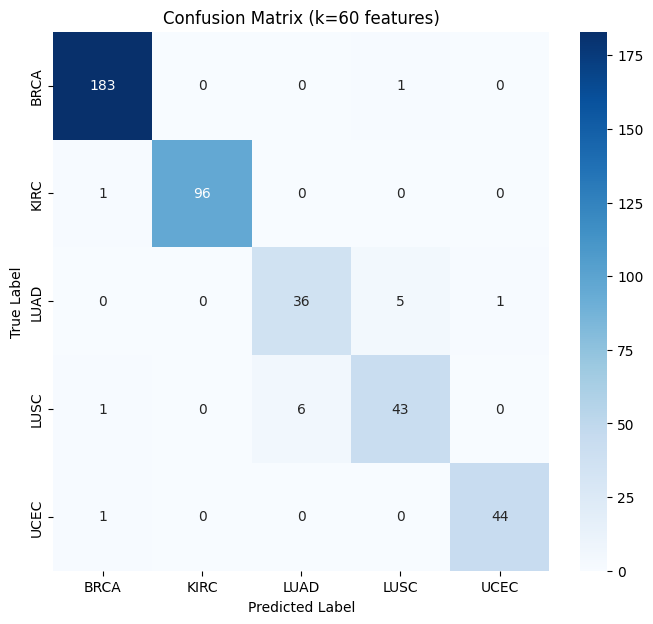


--- Confusion Matrix for Transformer Model (k=80 features) ---


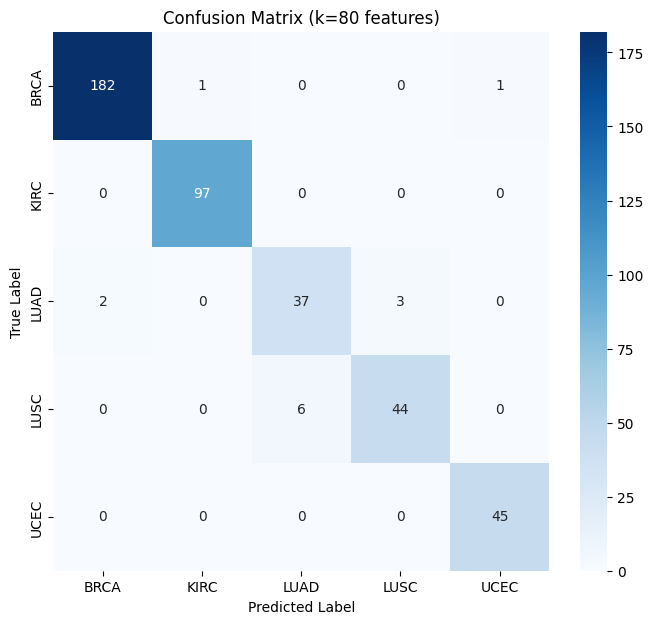


--- Confusion Matrix for Transformer Model (k=100 features) ---


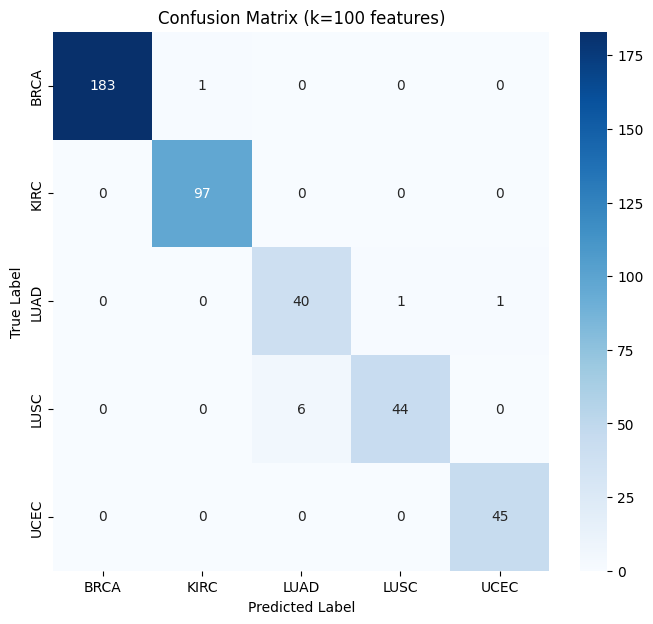


--- Confusion Matrix for Transformer Model (k=120 features) ---


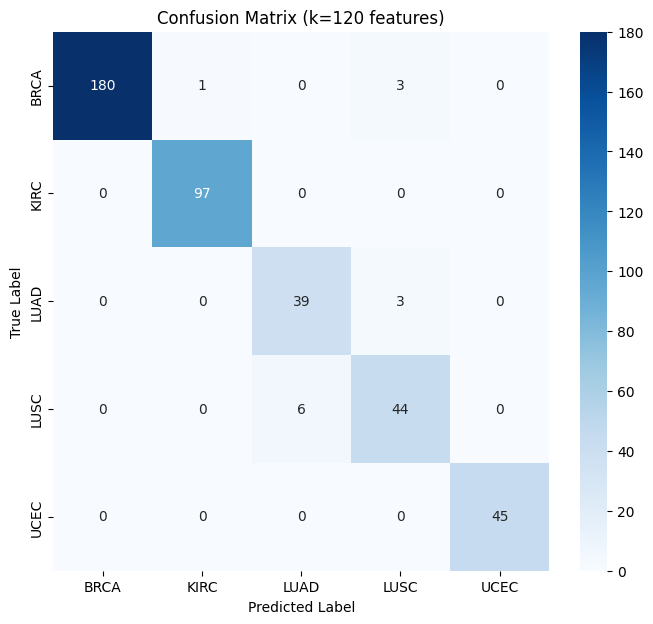

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for k in k_features_list_xgb_for_transformer:
    print(f"\n--- Confusion Matrix for Transformer Model (k={k} features) ---")
    cm = transformer_results_by_k[k]['Confusion Matrix']

    plt.figure(figsize=(8, 7)) # Increased size for better label visibility
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[class_labels[i] for i in range(num_classes)],
                yticklabels=[class_labels[i] for i in range(num_classes)])
    plt.title(f'Confusion Matrix (k={k} features)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    plt.close() # Close the plot to prevent it from displaying again if a later cell re-runs

In [ ]:
print("Confusion Matrix for Best Performing Transformer Model (k=100 features):")
display(transformer_results_by_k[100]['Confusion Matrix'])

Confusion Matrix for Best Performing Transformer Model (k=100 features):


array([[183,   1,   0,   0,   0],
       [  0,  97,   0,   0,   0],
       [  0,   0,  40,   1,   1],
       [  0,   0,   6,  44,   0],
       [  0,   0,   0,   0,  45]])

In [ ]:
# @title step_artifacts
num_fig = "2" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "ModelComparison"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig) # Commented out as function is not defined